## Lesson 4: Case Study - RFM Customer Segmentation

In [1]:
import numpy as np
import pandas as pd

In [57]:
df = pd.read_excel('Online_Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [58]:
df_clean = df.copy()

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [60]:
# step 2
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [61]:
df_clean['Description'] = df_clean['Description'].fillna('unknown')
df_clean['Description'].isnull().sum()

np.int64(0)

In [62]:
df_clean.dropna(subset=['CustomerID'], inplace=True)

In [63]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [64]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)

<Axes: >

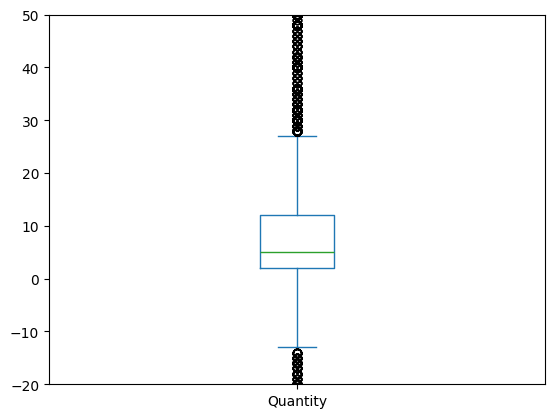

In [65]:
df_clean['Quantity'].plot(
    kind='box',
    ylim= (-20., 50. ),
)

In [66]:
df_clean[df_clean['Quantity'] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897,United Kingdom


In [67]:
df_clean.duplicated().shape

(406829,)

In [68]:
df_clean.drop_duplicates(inplace=True)

In [69]:
df_clean = df_clean[df_clean['Quantity'] > 0]

In [70]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice
count,392732.000000,392732,392732.000000
mean,13.153718,2011-07-10 19:15:24.576301568,3.125596
min,1.000000,2010-12-01 08:26:00,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000
50%,6.000000,2011-07-31 12:02:00,1.950000
75%,12.000000,2011-10-20 12:53:00,3.750000
max,80995.000000,2011-12-09 12:50:00,8142.750000
std,181.588420,NaN,22.240725


In [71]:
df_clean = df_clean[df_clean['InvoiceDate'] <= '2011-11-30']

In [72]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice
count,373602.000000,373602,373602.000000
mean,12.994272,2011-07-03 06:19:00.974513152,3.145236
min,1.000000,2010-12-01 08:26:00,0.000000
25%,2.000000,2011-04-01 10:11:00,1.250000
50%,6.000000,2011-07-20 10:08:00,1.950000
75%,12.000000,2011-10-11 12:36:00,3.750000
max,74215.000000,2011-11-29 18:14:00,8142.750000
std,130.495678,NaN,22.636300


In [73]:
now = df_clean['InvoiceDate'].max()+ pd.DateOffset(days=1) 
now 

Timestamp('2011-11-30 18:14:00')

In [74]:
# Step 3
df_clean['Total_Spend'] = df_clean['Quantity']*df_clean['UnitPrice']
rfm = df_clean.groupby("CustomerID").agg({'InvoiceDate': lambda x: (now - x.max()).days,
                                          'InvoiceNo' : 'nunique',
                                          'Total_Spend' : 'sum'})
rfm.head()


,InvoiceDate,InvoiceNo,Total_Spend
CustomerID,,,
12346,316,1,77183.60
12347,30,6,4085.18
12348,66,4,1797.24
12349,9,1,1757.55
12350,301,1,334.40


In [75]:
rfm.rename(columns={'InvoiceDate' : 'Recency',
                    'InvoiceNo' : 'Frequency',
                    'Total_Spend' : 'Monetary'}, inplace = True)
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,316,1,77183.60
12347,30,6,4085.18
12348,66,4,1797.24
12349,9,1,1757.55
12350,301,1,334.40


In [76]:
rfm.describe()

,Recency,Frequency,Monetary
count,4293.000000,4293.000000,4293.000000
mean,91.372700,4.113440,1940.046975
std,98.358017,7.397951,8346.295005
min,1.000000,1.000000,0.000000
25%,16.000000,1.000000,302.960000
50%,49.000000,2.000000,648.540000
75%,145.000000,4.000000,1590.220000
max,364.000000,201.000000,268478.000000


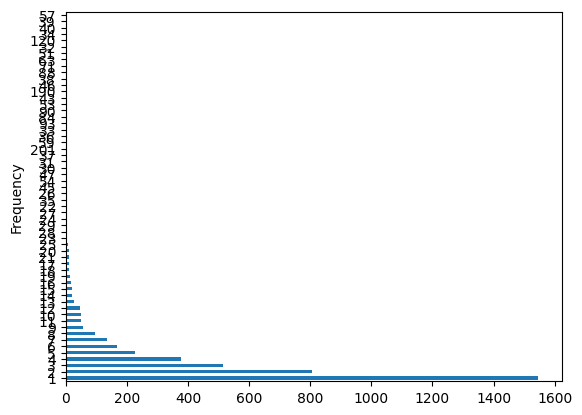

In [ ]:
rfm["Frequency"].value_counts().plot(kind='barh');

In [86]:
#Step 4:
rfm['r_score']=pd.qcut(rfm['Recency'],q=5,labels=[5,4,3,2,1])

In [89]:
rfm['f_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])

In [91]:
rfm[['Frequency','f_score']][rfm['Frequency']==1].value_counts()

Frequency  f_score
1          1          859
           2          687
Name: count, dtype: int64

In [92]:
rfm[['Frequency','f_score']][rfm['f_score']==2].value_counts()

Frequency  f_score
1          2          687
2          2          171
Name: count, dtype: int64

In [94]:
rfm['m_score'] = pd.qcut(rfm['Monetary'],q=5,labels=[1,2,3,4,5])

In [95]:
rfm

,Recency,Frequency,Monetary,r_score,f_score,m_score
CustomerID,,,,,,
12346,316,1,77183.60,1,1,5
12347,30,6,4085.18,4,5,5
12348,66,4,1797.24,3,4,4
12349,9,1,1757.55,5,1,4
12350,301,1,334.40,1,1,2
...,...,...,...,...,...,...
18280,268,1,180.60,1,2,1
18281,171,1,80.82,2,2,1
18282,117,1,100.21,2,2,1


In [98]:
rfm['rfm_score'] = rfm['r_score'].astype(str)+ rfm['f_score'].astype(str)+ rfm['m_score'].astype(str)

In [100]:
rfm['rf_score'] = rfm['r_score'].astype(str)+ rfm['f_score'].astype(str)

In [101]:
rfm.head()

,Recency,Frequency,Monetary,r_score,f_score,m_score,rfm_score,rf_score
CustomerID,,,,,,,,
12346,316,1,77183.60,1,1,5,115,11
12347,30,6,4085.18,4,5,5,455,45
12348,66,4,1797.24,3,4,4,344,34
12349,9,1,1757.55,5,1,4,514,51
12350,301,1,334.40,1,1,2,112,11


In [ ]:
segment_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At-Risk',
    r'[1-2]5': 'Cannot Lose Them',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}
rfm['Segment'] = rfm['rf_score'].replace(segment_map, regex=True)

In [103]:
rfm

,Recency,Frequency,Monetary,r_score,f_score,m_score,rfm_score,rf_score,Segment
CustomerID,,,,,,,,,
12346,316,1,77183.60,1,1,5,115,11,Hibernating
12347,30,6,4085.18,4,5,5,455,45,Loyal Customers
12348,66,4,1797.24,3,4,4,344,34,Loyal Customers
12349,9,1,1757.55,5,1,4,514,51,New Customers
12350,301,1,334.40,1,1,2,112,11,Hibernating
...,...,...,...,...,...,...,...,...,...
18280,268,1,180.60,1,2,1,121,12,Hibernating
18281,171,1,80.82,2,2,1,221,22,Hibernating
18282,117,1,100.21,2,2,1,221,22,Hibernating


In [106]:
rfm_plot_monetary = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

<Axes: ylabel='Segment'>

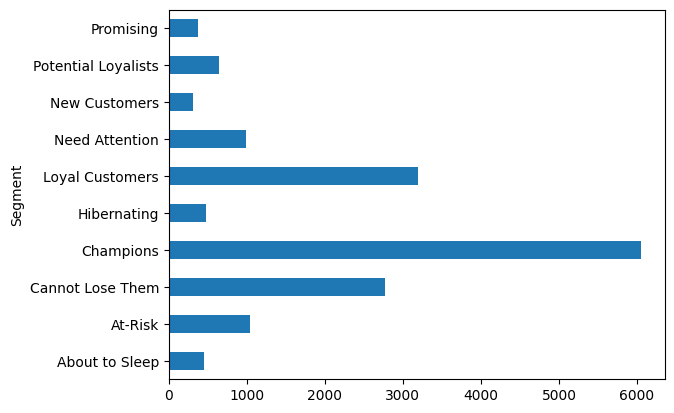

In [109]:
rfm_plot_monetary['Monetary'].plot(kind='barh')

In [110]:
segment_analysis = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)
segment_analysis


Recency Frequency Monetary      
                       mean      mean     mean count
Segment                                             
About to Sleep         51.2       1.1    455.7   346
At-Risk               153.6       2.8   1035.5   600
Cannot Lose Them      128.9       7.9   2776.0    73
Champions               6.7      11.3   6052.5   620
Hibernating           217.2       1.1    475.3  1026
Loyal Customers        32.9       6.7   3193.3   800
Need Attention         50.4       2.3    983.3   191
New Customers           7.1       1.0    306.2    64
Potential Loyalists    15.6       1.9    646.0   478
Promising              22.6       1.0    379.2    95

In [114]:
rfm[rfm['Segment']=='Champions']['rfm_score'].value_counts()

rfm_score
555    308
544    104
554     84
543     64
545     38
542     12
553      7
541      1
552      1
551      1
Name: count, dtype: int64